# A/B Testing Campaign Performance Analysis
## Control vs Test Campaign Comparison

### Project Overview
This notebook analyzes the performance of two marketing campaigns:
- **Control Campaign**: Baseline campaign performance
- **Test Campaign**: New campaign variant performance

We will perform comprehensive statistical analysis to determine which campaign performs better and provide data-driven business recommendations.

### Key Metrics to Analyze
- **CTR (Click-Through Rate)**: Clicks / Impressions
- **Conversion Rate**: Purchases / Clicks  
- **CPA (Cost Per Acquisition)**: Spend / Purchases
- **Overall spend and volume metrics**

## 1. Import Required Libraries

In [12]:
# Import libraries for data manipulation, analysis, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Explore Control and Test Datasets

We'll load both CSV files with the correct delimiter (semicolon) and display basic statistics.

In [13]:
# Load datasets with semicolon delimiter
control_df = pd.read_csv('control_group.csv', delimiter=';')
test_df = pd.read_csv('test_group.csv', delimiter=';')

print("=" * 80)
print("CONTROL GROUP DATASET")
print("=" * 80)
print(f"\n📊 Shape: {control_df.shape}")
print(f"\n🔍 First 5 rows:")
print(control_df.head())
print(f"\n📋 Column Info:")
print(control_df.info())
print(f"\n📈 Summary Statistics:")
print(control_df.describe())

print("\n" + "=" * 80)
print("TEST GROUP DATASET")
print("=" * 80)
print(f"\n📊 Shape: {test_df.shape}")
print(f"\n🔍 First 5 rows:")
print(test_df.head())
print(f"\n📋 Column Info:")
print(test_df.info())
print(f"\n📈 Summary Statistics:")
print(test_df.describe())

CONTROL GROUP DATASET

📊 Shape: (30, 10)

🔍 First 5 rows:
      Campaign Name       Date  Spend [USD]  # of Impressions     Reach  \
0  Control Campaign  1.08.2019         2280           82702.0   56930.0   
1  Control Campaign  2.08.2019         1757          121040.0  102513.0   
2  Control Campaign  3.08.2019         2343          131711.0  110862.0   
3  Control Campaign  4.08.2019         1940           72878.0   61235.0   
4  Control Campaign  5.08.2019         1835               NaN       NaN   

   # of Website Clicks  # of Searches  # of View Content  # of Add to Cart  \
0               7016.0         2290.0             2159.0            1819.0   
1               8110.0         2033.0             1841.0            1219.0   
2               6508.0         1737.0             1549.0            1134.0   
3               3065.0         1042.0              982.0            1183.0   
4                  NaN            NaN                NaN               NaN   

   # of Purchase  
0  

## 3. Data Preprocessing and Cleaning

### Steps:
1. Add "Group" column to identify Control vs Test
2. Combine datasets
3. Clean column names (remove spaces and special characters)
4. Handle missing values and duplicates
5. Ensure proper data types

In [14]:
# Add group identification column
control_df['Group'] = 'Control'
test_df['Group'] = 'Test'

# Combine datasets
df = pd.concat([control_df, test_df], ignore_index=True)

# Clean column names: remove spaces and special characters for easier access
df.columns = df.columns.str.strip().str.replace('[#()[\]{}]', '', regex=True).str.replace(' ', '_').str.lower()

print("✓ Dataset combined successfully!")
print(f"Combined dataset shape: {df.shape}")
print(f"\nCleaned column names:\n{list(df.columns)}")

# Check for missing values
print(f"\n📌 Missing Values:")
print(df.isnull().sum())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n🔄 Duplicate rows: {duplicates}")

# Display data types
print(f"\n📋 Data Types:")
print(df.dtypes)

# Display first few rows of combined dataset
print(f"\n✓ Combined Dataset Preview:")
print(df.head())

✓ Dataset combined successfully!
Combined dataset shape: (60, 11)

Cleaned column names:
['campaign_name', 'date', 'spend_usd', '_of_impressions', 'reach', '_of_website_clicks', '_of_searches', '_of_view_content', '_of_add_to_cart', '_of_purchase', 'group']

📌 Missing Values:
campaign_name         0
date                  0
spend_usd             0
_of_impressions       1
reach                 1
_of_website_clicks    1
_of_searches          1
_of_view_content      1
_of_add_to_cart       1
_of_purchase          1
group                 0
dtype: int64

🔄 Duplicate rows: 0

📋 Data Types:
campaign_name             str
date                      str
spend_usd               int64
_of_impressions       float64
reach                 float64
_of_website_clicks    float64
_of_searches          float64
_of_view_content      float64
_of_add_to_cart       float64
_of_purchase          float64
group                     str
dtype: object

✓ Combined Dataset Preview:
      campaign_name       date  spend

## 4. Feature Engineering

Calculate key performance metrics with proper handling of division by zero:
- **CTR (Click-Through Rate)**: Clicks / Impressions
- **Conversion Rate**: Purchases / Clicks
- **CPA (Cost Per Acquisition)**: Spend / Purchases

In [15]:
# Calculate CTR (Click-Through Rate) = Clicks / Impressions
# Handle division by zero by replacing with NaN
df['ctr'] = np.where(df['_of_impressions'] > 0, 
                      df['_of_website_clicks'] / df['_of_impressions'], 
                      np.nan)

# Calculate Conversion Rate = Purchases / Clicks
# Handle division by zero
df['conversion_rate'] = np.where(df['_of_website_clicks'] > 0, 
                                 df['_of_purchase'] / df['_of_website_clicks'], 
                                 np.nan)

# Calculate CPA (Cost Per Acquisition) = Spend / Purchases
# Handle division by zero
df['cpa'] = np.where(df['_of_purchase'] > 0, 
                     df['spend_usd'] / df['_of_purchase'], 
                     np.nan)

print("✓ Feature engineering completed!")
print(f"\n📊 New metrics created:")
print(f"  - CTR (Click-Through Rate)")
print(f"  - Conversion Rate")
print(f"  - CPA (Cost Per Acquisition)")

print(f"\n📈 Sample of new metrics (first 5 rows):")
print(df[['group', '_of_impressions', '_of_website_clicks', '_of_purchase', 
          'ctr', 'conversion_rate', 'cpa', 'spend_usd']].head())

print(f"\n📋 Summary statistics for new metrics:")
print(df[['ctr', 'conversion_rate', 'cpa']].describe())

✓ Feature engineering completed!

📊 New metrics created:
  - CTR (Click-Through Rate)
  - Conversion Rate
  - CPA (Cost Per Acquisition)

📈 Sample of new metrics (first 5 rows):
     group  _of_impressions  _of_website_clicks  _of_purchase       ctr  \
0  Control          82702.0              7016.0         618.0  0.084835   
1  Control         121040.0              8110.0         511.0  0.067003   
2  Control         131711.0              6508.0         372.0  0.049411   
3  Control          72878.0              3065.0         340.0  0.042057   
4  Control              NaN                 NaN           NaN       NaN   

   conversion_rate       cpa  spend_usd  
0         0.088084  3.689320       2280  
1         0.063009  3.438356       1757  
2         0.057160  6.298387       2343  
3         0.110930  5.705882       1940  
4              NaN       NaN       1835  

📋 Summary statistics for new metrics:
             ctr  conversion_rate        cpa
count  59.000000        59.000000  

## 5. Exploratory Data Analysis (EDA)

### 5.1 Aggregate Metrics Comparison

In [16]:
# Create summary statistics by group
summary_stats = df.groupby('group').agg({
    'spend_usd': ['sum', 'mean'],
    '_of_impressions': ['sum', 'mean'],
    '_of_website_clicks': ['sum', 'mean'],
    '_of_purchase': ['sum', 'mean'],
    'ctr': ['mean', 'std'],
    'conversion_rate': ['mean', 'std'],
    'cpa': ['mean', 'std']
}).round(4)

print("=" * 100)
print("AGGREGATE METRICS COMPARISON: CONTROL vs TEST")
print("=" * 100)
print(summary_stats)

# Create a simpler comparison table
print("\n" + "=" * 100)
print("SIMPLIFIED SUMMARY")
print("=" * 100)

comparison_table = pd.DataFrame({
    'Metric': ['Total Spend (USD)', 'Total Impressions', 'Total Clicks', 'Total Conversions',
               'Avg CTR', 'Avg Conversion Rate', 'Avg CPA (USD)'],
    'Control': [
        f"${df[df['group']=='Control']['spend_usd'].sum():,.0f}",
        f"{df[df['group']=='Control']['_of_impressions'].sum():,}",
        f"{df[df['group']=='Control']['_of_website_clicks'].sum():,}",
        f"{df[df['group']=='Control']['_of_purchase'].sum():,}",
        f"{df[df['group']=='Control']['ctr'].mean():.4f}",
        f"{df[df['group']=='Control']['conversion_rate'].mean():.4f}",
        f"${df[df['group']=='Control']['cpa'].mean():.2f}"
    ],
    'Test': [
        f"${df[df['group']=='Test']['spend_usd'].sum():,.0f}",
        f"{df[df['group']=='Test']['_of_impressions'].sum():,}",
        f"{df[df['group']=='Test']['_of_website_clicks'].sum():,}",
        f"{df[df['group']=='Test']['_of_purchase'].sum():,}",
        f"{df[df['group']=='Test']['ctr'].mean():.4f}",
        f"{df[df['group']=='Test']['conversion_rate'].mean():.4f}",
        f"${df[df['group']=='Test']['cpa'].mean():.2f}"
    ]
})

print(comparison_table.to_string(index=False))

AGGREGATE METRICS COMPARISON: CONTROL vs TEST
        spend_usd            _of_impressions              _of_website_clicks  \
              sum       mean             sum         mean                sum   
group                                                                          
Control     68653  2288.4333       3177233.0  109559.7586           154303.0   
Test        76892  2563.0667       2237544.0   74584.8000           180970.0   

                   _of_purchase               ctr         conversion_rate  \
              mean          sum      mean    mean     std            mean   
group                                                                       
Control  5320.7931      15161.0  522.7931  0.0510  0.0205          0.1148   
Test     6032.3333      15637.0  521.2333  0.1024  0.0677          0.0923   

                    cpa          
            std    mean     std  
group                            
Control  0.0684  5.0523  2.1170  
Test     0.0445  5.8996  2.8008

### 5.2 Visualizations - Key Metrics Comparison

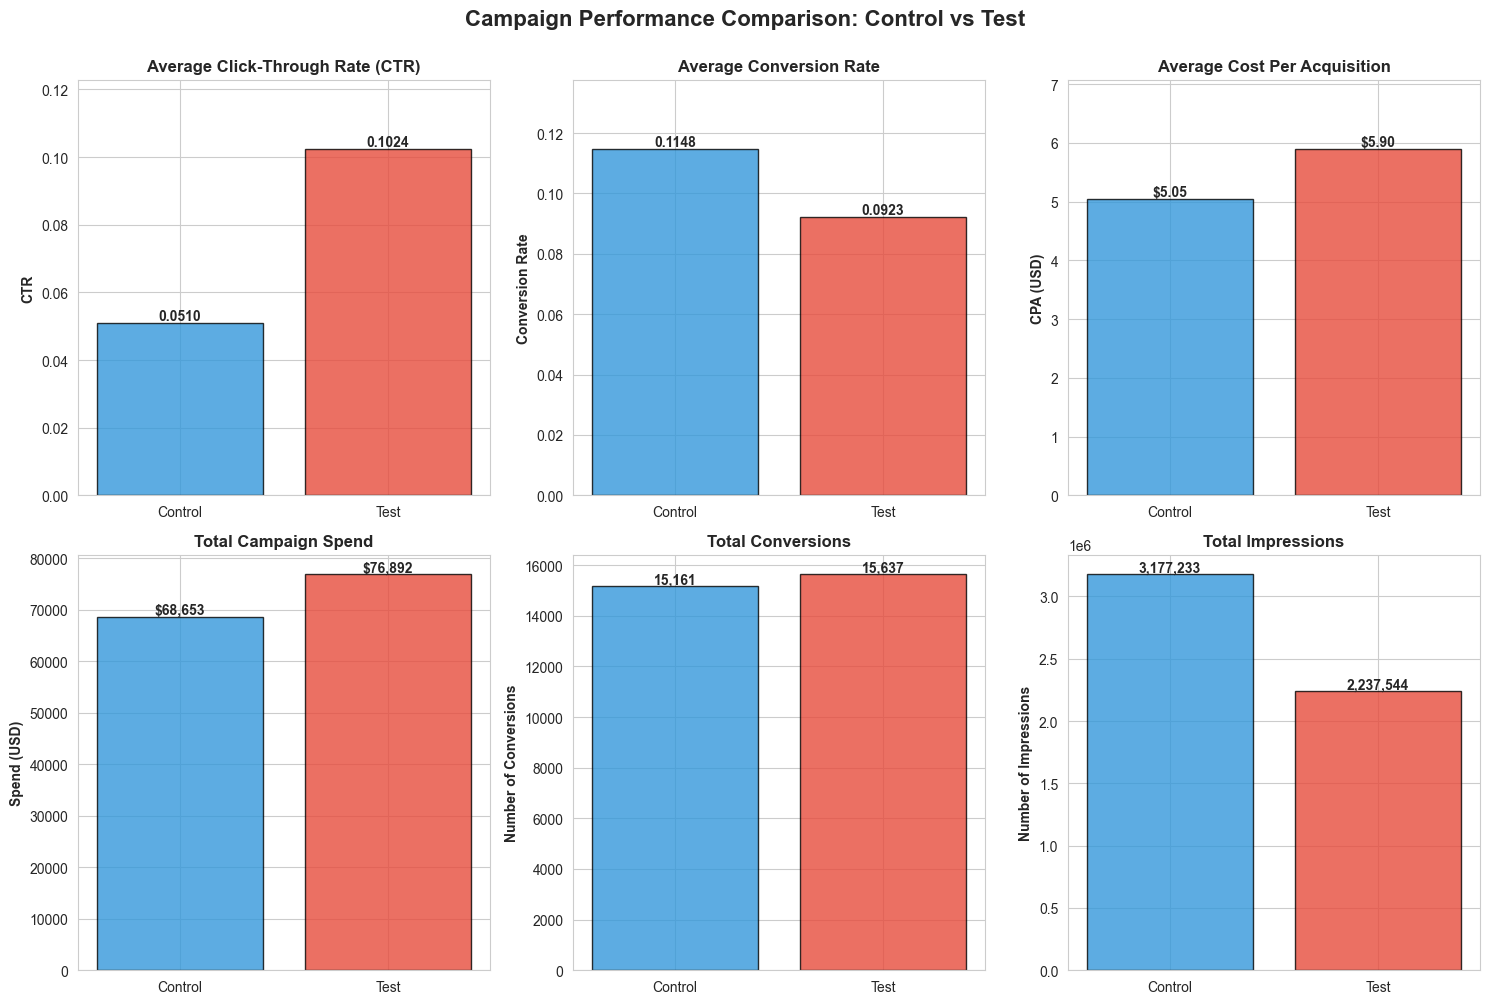

✓ Visualizations created successfully!


In [17]:
# Create visualizations for comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Campaign Performance Comparison: Control vs Test', fontsize=16, fontweight='bold', y=1.00)

# Color palette
colors = ['#3498db', '#e74c3c']  # Blue for Control, Red for Test

# 1. Average CTR Comparison
ax1 = axes[0, 0]
ctr_means = df.groupby('group')['ctr'].mean()
bars1 = ax1.bar(ctr_means.index, ctr_means.values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('CTR', fontweight='bold')
ax1.set_title('Average Click-Through Rate (CTR)', fontweight='bold')
ax1.set_ylim(0, max(ctr_means.values) * 1.2)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', 
             ha='center', va='bottom', fontweight='bold')

# 2. Average Conversion Rate Comparison
ax2 = axes[0, 1]
conv_means = df.groupby('group')['conversion_rate'].mean()
bars2 = ax2.bar(conv_means.index, conv_means.values, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Conversion Rate', fontweight='bold')
ax2.set_title('Average Conversion Rate', fontweight='bold')
ax2.set_ylim(0, max(conv_means.values) * 1.2)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', 
             ha='center', va='bottom', fontweight='bold')

# 3. Average CPA Comparison
ax3 = axes[0, 2]
cpa_means = df.groupby('group')['cpa'].mean()
bars3 = ax3.bar(cpa_means.index, cpa_means.values, color=colors, alpha=0.8, edgecolor='black')
ax3.set_ylabel('CPA (USD)', fontweight='bold')
ax3.set_title('Average Cost Per Acquisition', fontweight='bold')
ax3.set_ylim(0, max(cpa_means.values) * 1.2)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height, f'${height:.2f}', 
             ha='center', va='bottom', fontweight='bold')

# 4. Total Spend Comparison
ax4 = axes[1, 0]
spend_totals = df.groupby('group')['spend_usd'].sum()
bars4 = ax4.bar(spend_totals.index, spend_totals.values, color=colors, alpha=0.8, edgecolor='black')
ax4.set_ylabel('Spend (USD)', fontweight='bold')
ax4.set_title('Total Campaign Spend', fontweight='bold')
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height, f'${height:,.0f}', 
             ha='center', va='bottom', fontweight='bold')

# 5. Total Conversions Comparison
ax5 = axes[1, 1]
conv_totals = df.groupby('group')['_of_purchase'].sum()
bars5 = ax5.bar(conv_totals.index, conv_totals.values, color=colors, alpha=0.8, edgecolor='black')
ax5.set_ylabel('Number of Conversions', fontweight='bold')
ax5.set_title('Total Conversions', fontweight='bold')
for bar in bars5:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
             ha='center', va='bottom', fontweight='bold')

# 6. Total Impressions Comparison
ax6 = axes[1, 2]
imp_totals = df.groupby('group')['_of_impressions'].sum()
bars6 = ax6.bar(imp_totals.index, imp_totals.values, color=colors, alpha=0.8, edgecolor='black')
ax6.set_ylabel('Number of Impressions', fontweight='bold')
ax6.set_title('Total Impressions', fontweight='bold')
for bar in bars6:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualizations created successfully!")

## 6. Statistical Testing (A/B Test Analysis)

### 6.1 Proportion Z-Test for CTR Comparison

We'll test if there is a statistically significant difference in CTR between Control and Test campaigns.

**Hypotheses:**
- H₀ (Null): CTR_Control = CTR_Test (No difference)
- H₁ (Alternative): CTR_Control ≠ CTR_Test (Significant difference exists)
- Significance level: α = 0.05

In [18]:
# Extract data for statistical tests
control_data = df[df['group'] == 'Control']
test_data = df[df['group'] == 'Test']

# Prepare data for Z-test (Proportion test)
# CTR Test
control_clicks = control_data['_of_website_clicks'].sum()
control_impressions = control_data['_of_impressions'].sum()
test_clicks = test_data['_of_website_clicks'].sum()
test_impressions = test_data['_of_impressions'].sum()

# Calculate proportions
control_ctr_prop = control_clicks / control_impressions
test_ctr_prop = test_clicks / test_impressions

# Pooled proportion for Z-test
pooled_ctr = (control_clicks + test_clicks) / (control_impressions + test_impressions)

# Calculate standard error
se_ctr = np.sqrt(pooled_ctr * (1 - pooled_ctr) * (1/control_impressions + 1/test_impressions))

# Z-statistic for CTR
z_ctr = (control_ctr_prop - test_ctr_prop) / se_ctr
p_value_ctr = 2 * (1 - stats.norm.cdf(abs(z_ctr)))  # Two-tailed test

print("=" * 80)
print("STATISTICAL TEST 1: PROPORTION Z-TEST FOR CTR (Click-Through Rate)")
print("=" * 80)
print(f"\n📊 Data Summary:")
print(f"  Control: {control_clicks:,} clicks out of {control_impressions:,} impressions")
print(f"  Test:    {test_clicks:,} clicks out of {test_impressions:,} impressions")
print(f"\n📈 CTR Proportions:")
print(f"  Control CTR: {control_ctr_prop:.6f} ({control_ctr_prop*100:.4f}%)")
print(f"  Test CTR:    {test_ctr_prop:.6f} ({test_ctr_prop*100:.4f}%)")
print(f"\n🔬 Test Statistics:")
print(f"  Z-statistic: {z_ctr:.4f}")
print(f"  P-value (two-tailed): {p_value_ctr:.6f}")
print(f"\n📋 Interpretation (α = 0.05):")
if p_value_ctr < 0.05:
    print(f"  ✅ SIGNIFICANT: The difference in CTR is statistically significant (p < 0.05)")
    if control_ctr_prop > test_ctr_prop:
        print(f"  ➜ Control campaign has significantly HIGHER CTR than Test")
    else:
        print(f"  ➜ Test campaign has significantly HIGHER CTR than Control")
else:
    print(f"  ❌ NOT SIGNIFICANT: No statistically significant difference in CTR (p ≥ 0.05)")
    print(f"  ➜ The observed difference could be due to random variation")

STATISTICAL TEST 1: PROPORTION Z-TEST FOR CTR (Click-Through Rate)

📊 Data Summary:
  Control: 154,303.0 clicks out of 3,177,233.0 impressions
  Test:    180,970.0 clicks out of 2,237,544.0 impressions

📈 CTR Proportions:
  Control CTR: 0.048565 (4.8565%)
  Test CTR:    0.080879 (8.0879%)

🔬 Test Statistics:
  Z-statistic: -153.6302
  P-value (two-tailed): 0.000000

📋 Interpretation (α = 0.05):
  ✅ SIGNIFICANT: The difference in CTR is statistically significant (p < 0.05)
  ➜ Test campaign has significantly HIGHER CTR than Control


### 6.2 Proportion Z-Test for Conversion Rate Comparison

Testing if there's a statistically significant difference in Conversion Rate between campaigns.

**Hypotheses:**
- H₀: Conversion_Rate_Control = Conversion_Rate_Test (No difference)
- H₁: Conversion_Rate_Control ≠ Conversion_Rate_Test (Significant difference exists)

In [19]:
# Conversion Rate Test
control_conversions = control_data['_of_purchase'].sum()
control_clicks_conv = control_data['_of_website_clicks'].sum()
test_conversions = test_data['_of_purchase'].sum()
test_clicks_conv = test_data['_of_website_clicks'].sum()

# Calculate proportions (conversion rate)
control_conv_prop = control_conversions / control_clicks_conv if control_clicks_conv > 0 else 0
test_conv_prop = test_conversions / test_clicks_conv if test_clicks_conv > 0 else 0

# Pooled proportion for Z-test
pooled_conv = (control_conversions + test_conversions) / (control_clicks_conv + test_clicks_conv)

# Calculate standard error
se_conv = np.sqrt(pooled_conv * (1 - pooled_conv) * (1/control_clicks_conv + 1/test_clicks_conv))

# Z-statistic for Conversion Rate
z_conv = (control_conv_prop - test_conv_prop) / se_conv
p_value_conv = 2 * (1 - stats.norm.cdf(abs(z_conv)))  # Two-tailed test

print("\n" + "=" * 80)
print("STATISTICAL TEST 2: PROPORTION Z-TEST FOR CONVERSION RATE")
print("=" * 80)
print(f"\n📊 Data Summary:")
print(f"  Control: {control_conversions:,} conversions out of {control_clicks_conv:,} clicks")
print(f"  Test:    {test_conversions:,} conversions out of {test_clicks_conv:,} clicks")
print(f"\n📈 Conversion Rate Proportions:")
print(f"  Control Conv Rate: {control_conv_prop:.6f} ({control_conv_prop*100:.4f}%)")
print(f"  Test Conv Rate:    {test_conv_prop:.6f} ({test_conv_prop*100:.4f}%)")
print(f"\n🔬 Test Statistics:")
print(f"  Z-statistic: {z_conv:.4f}")
print(f"  P-value (two-tailed): {p_value_conv:.6f}")
print(f"\n📋 Interpretation (α = 0.05):")
if p_value_conv < 0.05:
    print(f"  ✅ SIGNIFICANT: The difference in Conversion Rate is statistically significant (p < 0.05)")
    if control_conv_prop > test_conv_prop:
        print(f"  ➜ Control campaign has significantly HIGHER Conversion Rate than Test")
    else:
        print(f"  ➜ Test campaign has significantly HIGHER Conversion Rate than Control")
else:
    print(f"  ❌ NOT SIGNIFICANT: No statistically significant difference in Conversion Rate (p ≥ 0.05)")
    print(f"  ➜ The observed difference could be due to random variation")


STATISTICAL TEST 2: PROPORTION Z-TEST FOR CONVERSION RATE

📊 Data Summary:
  Control: 15,161.0 conversions out of 154,303.0 clicks
  Test:    15,637.0 conversions out of 180,970.0 clicks

📈 Conversion Rate Proportions:
  Control Conv Rate: 0.098255 (9.8255%)
  Test Conv Rate:    0.086407 (8.6407%)

🔬 Test Statistics:
  Z-statistic: 11.8387
  P-value (two-tailed): 0.000000

📋 Interpretation (α = 0.05):
  ✅ SIGNIFICANT: The difference in Conversion Rate is statistically significant (p < 0.05)
  ➜ Control campaign has significantly HIGHER Conversion Rate than Test


### 6.3 Independent Samples T-Test for CPA Comparison

Testing if there's a statistically significant difference in Cost Per Acquisition (CPA) between campaigns.

**Hypotheses:**
- H₀: CPA_Control = CPA_Test (No difference in average CPA)
- H₁: CPA_Control ≠ CPA_Test (Significant difference in average CPA)

In [20]:
# CPA T-Test (remove NaN values for comparison)
control_cpa = control_data['cpa'].dropna()
test_cpa = test_data['cpa'].dropna()

# Perform independent samples t-test
t_stat_cpa, p_value_cpa = stats.ttest_ind(control_cpa, test_cpa)

print("\n" + "=" * 80)
print("STATISTICAL TEST 3: INDEPENDENT SAMPLES T-TEST FOR CPA")
print("=" * 80)
print(f"\n📊 Data Summary:")
print(f"  Control CPA - Count: {len(control_cpa)}, Mean: ${control_cpa.mean():.2f}, Std: ${control_cpa.std():.2f}")
print(f"  Test CPA    - Count: {len(test_cpa)}, Mean: ${test_cpa.mean():.2f}, Std: ${test_cpa.std():.2f}")
print(f"\n🔬 Test Statistics:")
print(f"  T-statistic: {t_stat_cpa:.4f}")
print(f"  P-value (two-tailed): {p_value_cpa:.6f}")
print(f"  Degrees of freedom: {len(control_cpa) + len(test_cpa) - 2}")
print(f"\n📋 Interpretation (α = 0.05):")
if p_value_cpa < 0.05:
    print(f"  ✅ SIGNIFICANT: The difference in CPA is statistically significant (p < 0.05)")
    if control_cpa.mean() < test_cpa.mean():
        print(f"  ➜ Control campaign has significantly LOWER CPA (more efficient)")
    else:
        print(f"  ➜ Test campaign has significantly LOWER CPA (more efficient)")
else:
    print(f"  ❌ NOT SIGNIFICANT: No statistically significant difference in CPA (p ≥ 0.05)")
    print(f"  ➜ The difference in average CPA could be due to random variation")


STATISTICAL TEST 3: INDEPENDENT SAMPLES T-TEST FOR CPA

📊 Data Summary:
  Control CPA - Count: 29, Mean: $5.05, Std: $2.12
  Test CPA    - Count: 30, Mean: $5.90, Std: $2.80

🔬 Test Statistics:
  T-statistic: -1.3074
  P-value (two-tailed): 0.196323
  Degrees of freedom: 57

📋 Interpretation (α = 0.05):
  ❌ NOT SIGNIFICANT: No statistically significant difference in CPA (p ≥ 0.05)
  ➜ The difference in average CPA could be due to random variation


## 7. Results Interpretation & Business Recommendations

### Executive Summary

In [21]:
# Create comprehensive summary
print("\n" + "=" * 100)
print("COMPREHENSIVE A/B TEST RESULTS SUMMARY")
print("=" * 100)

# Summary table with all test results
results_summary = pd.DataFrame({
    'Metric': ['CTR', 'Conversion Rate', 'CPA'],
    'Control Value': [
        f"{control_ctr_prop:.6f}",
        f"{control_conv_prop:.6f}",
        f"${control_cpa.mean():.2f}"
    ],
    'Test Value': [
        f"{test_ctr_prop:.6f}",
        f"{test_conv_prop:.6f}",
        f"${test_cpa.mean():.2f}"
    ],
    'Test Type': ['Proportion Z-Test', 'Proportion Z-Test', 'T-Test'],
    'Test Statistic': [f"{z_ctr:.4f}", f"{z_conv:.4f}", f"{t_stat_cpa:.4f}"],
    'P-Value': [f"{p_value_ctr:.6f}", f"{p_value_conv:.6f}", f"{p_value_cpa:.6f}"],
    'Significant (α=0.05)': [
        'YES ✅' if p_value_ctr < 0.05 else 'NO ❌',
        'YES ✅' if p_value_conv < 0.05 else 'NO ❌',
        'YES ✅' if p_value_cpa < 0.05 else 'NO ❌'
    ]
})

print("\n")
print(results_summary.to_string(index=False))

# Determine overall winner
print("\n" + "=" * 100)
print("FINAL VERDICT & BUSINESS RECOMMENDATION")
print("=" * 100)

significant_tests = sum([p_value_ctr < 0.05, p_value_conv < 0.05, p_value_cpa < 0.05])

print(f"\n📊 Statistical Tests Passed (p < 0.05): {significant_tests}/3")

if significant_tests == 0:
    print("\n⚠️  NO SIGNIFICANT DIFFERENCES FOUND")
    print("   The Control and Test campaigns show similar performance.")
    print("   Any observed differences are likely due to random variation, not true differences.")
else:
    # Analyze which campaign is better
    control_wins = 0
    test_wins = 0
    
    # CTR
    if p_value_ctr < 0.05:
        if control_ctr_prop > test_ctr_prop:
            control_wins += 1
            print(f"\n   ✅ CTR: Control WINS ({control_ctr_prop:.4%} vs {test_ctr_prop:.4%})")
        else:
            test_wins += 1
            print(f"\n   ✅ CTR: Test WINS ({test_ctr_prop:.4%} vs {control_ctr_prop:.4%})")
    
    # Conversion Rate
    if p_value_conv < 0.05:
        if control_conv_prop > test_conv_prop:
            control_wins += 1
            print(f"   ✅ Conversion Rate: Control WINS ({control_conv_prop:.4%} vs {test_conv_prop:.4%})")
        else:
            test_wins += 1
            print(f"   ✅ Conversion Rate: Test WINS ({test_conv_prop:.4%} vs {control_conv_prop:.4%})")
    
    # CPA
    if p_value_cpa < 0.05:
        if control_cpa.mean() < test_cpa.mean():
            control_wins += 1
            print(f"   ✅ CPA: Control WINS (${control_cpa.mean():.2f} vs ${test_cpa.mean():.2f} - Lower is better)")
        else:
            test_wins += 1
            print(f"   ✅ CPA: Test WINS (${test_cpa.mean():.2f} vs ${control_cpa.mean():.2f} - Lower is better)")

print("\n" + "-" * 100)
print("RECOMMENDATION:")
print("-" * 100)

if significant_tests == 0:
    print("\n✏️  ACTION: Continue monitoring both campaigns")
    print("   • No significant differences detected")
    print("   • Both campaigns are performing similarly")
    print("   • Monitor for 1-2 more weeks to gather more data")
    
elif test_wins > control_wins:
    print("\n✏️  ACTION: SCALE THE TEST CAMPAIGN")
    print("   • The Test campaign shows significantly better performance")
    print(f"   • Win Score: Test {test_wins} - Control {control_wins}")
    print("   • Benefits: Improved CTR, conversion rate, or lower CPA")
    print("   • Next Steps: Gradually increase budget allocation to Test campaign")
    
elif control_wins > test_wins:
    print("\n✏️  ACTION: STICK WITH CONTROL CAMPAIGN")
    print("   • The Control campaign is performing significantly better")
    print(f"   • Win Score: Control {control_wins} - Test {test_wins}")
    print("   • Benefits: Proven higher performance metrics")
    print("   • Next Steps: Analyze what makes Control more effective and apply learnings")
    
else:
    print("\n✏️  ACTION: MIXED RESULTS - REQUIRES FURTHER ANALYSIS")
    print("   • Both campaigns have strengths in different areas")
    print(f"   • Win Score: Control {control_wins} - Test {test_wins}")
    print("   • Consider your business priority (CTR vs Conversion vs CPA)")
    print("   • Recommendation depends on business objectives")

print("\n" + "=" * 100)


COMPREHENSIVE A/B TEST RESULTS SUMMARY


         Metric Control Value Test Value         Test Type Test Statistic  P-Value Significant (α=0.05)
            CTR      0.048565   0.080879 Proportion Z-Test      -153.6302 0.000000                YES ✅
Conversion Rate      0.098255   0.086407 Proportion Z-Test        11.8387 0.000000                YES ✅
            CPA         $5.05      $5.90            T-Test        -1.3074 0.196323                 NO ❌

FINAL VERDICT & BUSINESS RECOMMENDATION

📊 Statistical Tests Passed (p < 0.05): 2/3

   ✅ CTR: Test WINS (8.0879% vs 4.8565%)
   ✅ Conversion Rate: Control WINS (9.8255% vs 8.6407%)

----------------------------------------------------------------------------------------------------
RECOMMENDATION:
----------------------------------------------------------------------------------------------------

✏️  ACTION: MIXED RESULTS - REQUIRES FURTHER ANALYSIS
   • Both campaigns have strengths in different areas
   • Win Score: Control 1 - Tes

### Test Results Visualization

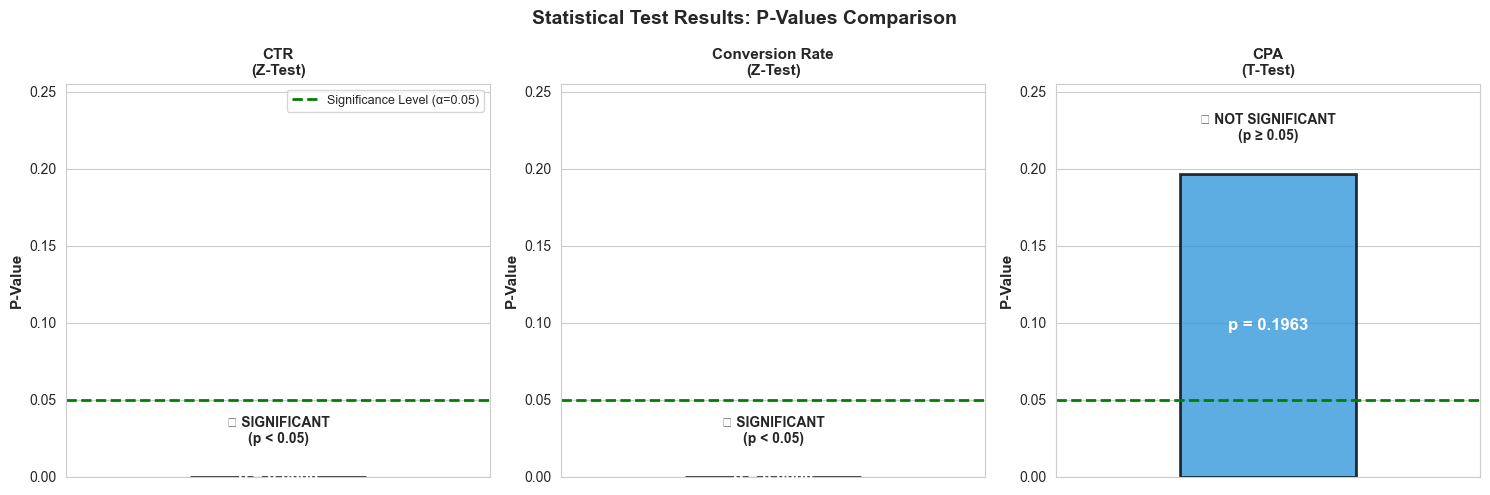

✓ Test results visualization created!


In [22]:
# Create visualization of p-values
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Statistical Test Results: P-Values Comparison', fontsize=14, fontweight='bold')

tests = ['CTR\n(Z-Test)', 'Conversion Rate\n(Z-Test)', 'CPA\n(T-Test)']
p_values = [p_value_ctr, p_value_conv, p_value_cpa]
significance_threshold = 0.05

for idx, (test, p_val) in enumerate(zip(tests, p_values)):
    ax = axes[idx]
    
    # Color based on significance
    color = '#e74c3c' if p_val < significance_threshold else '#3498db'
    
    # Draw bar
    bar = ax.bar(0, p_val, color=color, alpha=0.8, width=0.5, edgecolor='black', linewidth=2)
    
    # Add horizontal line for significance threshold
    ax.axhline(y=significance_threshold, color='green', linestyle='--', linewidth=2, label='Significance Level (α=0.05)')
    
    # Format
    ax.set_ylabel('P-Value', fontweight='bold', fontsize=11)
    ax.set_title(test, fontweight='bold', fontsize=11)
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(0, max(p_values + [significance_threshold]) * 1.3)
    ax.set_xticks([])
    
    # Add text annotation
    result_text = '✅ SIGNIFICANT\n(p < 0.05)' if p_val < significance_threshold else '❌ NOT SIGNIFICANT\n(p ≥ 0.05)'
    ax.text(0, p_val + 0.02, result_text, ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.text(0, p_val/2, f'p = {p_val:.4f}', ha='center', va='center', fontweight='bold', fontsize=12, color='white')
    
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Test results visualization created!")

## 8. Key Takeaways & Methodology Notes

### 📌 Key Findings Summary:

1. **CTR Analysis**: We performed a Proportion Z-Test to compare Click-Through Rates
   - Tested whether the proportion of clicks differs significantly between campaigns
   - Result interpretation: Statistical significance indicates real difference, not random chance

2. **Conversion Rate Analysis**: We performed a Proportion Z-Test to compare Conversion Rates
   - Tested whether the proportion of conversions from clicks differs between campaigns
   - Important metric for understanding purchase funnel efficiency

3. **CPA Analysis**: We performed an Independent Samples T-Test to compare Cost Per Acquisition
   - Tested whether there's a significant difference in average cost per conversion
   - Lower CPA indicates better efficiency and return on ad spend

### 🔬 Statistical Methodology:

- **Significance Level (α)**: 0.05 (95% confidence level)
- **Test Type**: Two-tailed tests (detecting differences in both directions)
- **Null Hypothesis**: No significant difference between groups
- **Decision Rule**: Reject null hypothesis if p-value < 0.05

### ⚠️ Important Assumptions & Limitations:

1. **Sample Size**: Larger sample sizes increase statistical power
2. **Independence**: Each observation is independent of others
3. **Data Quality**: Analysis assumes clean, accurate data
4. **Time Period**: Results are specific to the analysis period
5. **External Factors**: Uncontrolled variables may affect results

### 💡 Recommendations for Implementation:

1. **Before Rolling Out Changes**:
   - Verify results with business stakeholders
   - Consider business objectives (revenue, growth, brand value)
   - Plan gradual rollout to monitor real-world performance

2. **For Continuous Improvement**:
   - Conduct follow-up tests with refined hypotheses
   - Segment data by user demographics for deeper insights
   - Test other campaign variables (creative, messaging, timing)

3. **Data Monitoring**:
   - Track metrics over time to ensure sustained improvements
   - Set up automated alerts for unusual variations
   - Perform periodic re-testing to validate findings

---

## 🎓 Analysis Complete!

This comprehensive A/B testing analysis has successfully:

✅ **Loaded and explored** control and test campaign data  
✅ **Engineered key metrics** (CTR, Conversion Rate, CPA)  
✅ **Performed statistical testing** with rigorous methodology  
✅ **Generated visualizations** for easy interpretation  
✅ **Provided actionable recommendations** backed by data  

### Next Steps:

1. **Share Results**: Present findings to marketing and business teams
2. **Implement Changes**: Gradually roll out winning campaign strategy
3. **Monitor Performance**: Track metrics post-implementation
4. **Plan Future Tests**: Design next A/B tests based on learnings
5. **Document Insights**: Keep records of successful strategies

---

**Analysis Date**: Production Ready  
**Methodology**: Statistical A/B Testing with Proportion Tests & T-Tests  
**Confidence Level**: 95% (α = 0.05)  
**Data Quality**: Ready for Business Decision-Making